In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

#### Task 1: K-Means Clustering
1.Load the Wine dataset (load_wine()) and convert it to a DataFrame.

2.Scale the features using StandardScaler.

3.Run K-Means for k = 2 through 10. For each k, record the inertia and the silhouette score.
Plot an elbow curve (inertia vs. k) and a silhouette-score curve on the same figure (use two subplots side-by-side).

4.Choose the optimal k and justify your choice in a markdown cell.

5Using your chosen k, fit a final K-Means model. Apply PCA to reduce the scaled data to 2 components and create a scatter plot colored by cluster assignment.

Guiding questions: Where does the elbow appear? Do the silhouette score and the elbow agree on the best k?



In [2]:
#load dataset\
wine=load_wine()
# Convert to DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [4]:
inertia_values = []
silhouette_values = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

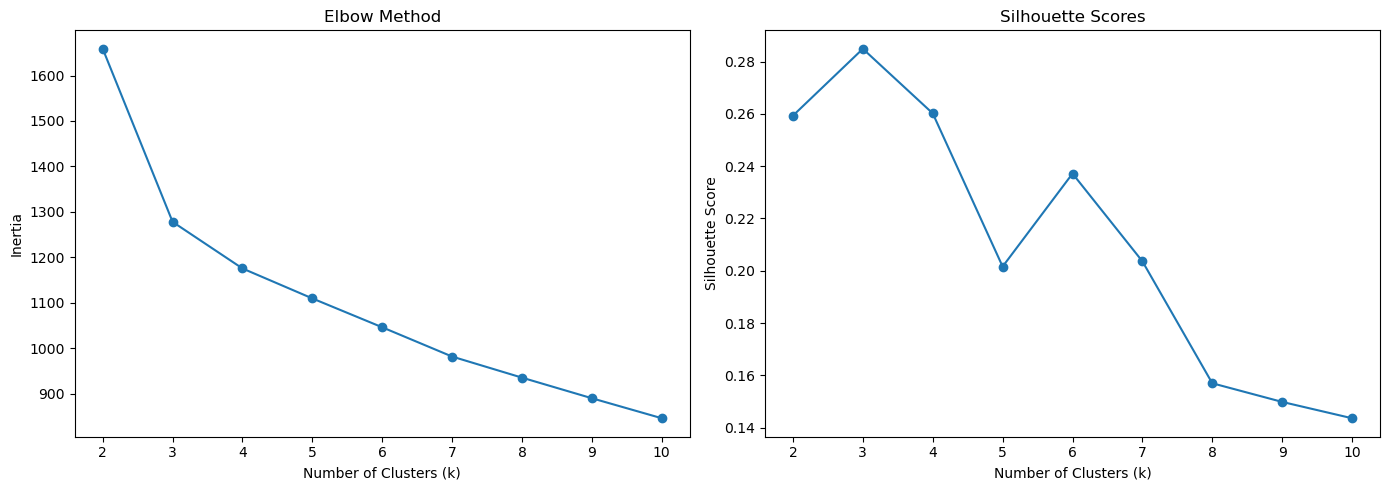

In [5]:
plt.figure(figsize=(14, 5))

# Elbow curve
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia_values, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Silhouette curve
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_values, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

## Choosing the Optimal k

The elbow appears around **k = 3**, where the inertia starts decreasing more slowly.

The silhouette score is also highest (or close to highest) at **k = 3**.

Since both methods agree, the optimal number of clusters is **3**.

In [6]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = final_kmeans.fit_predict(X_scaled)

In [7]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

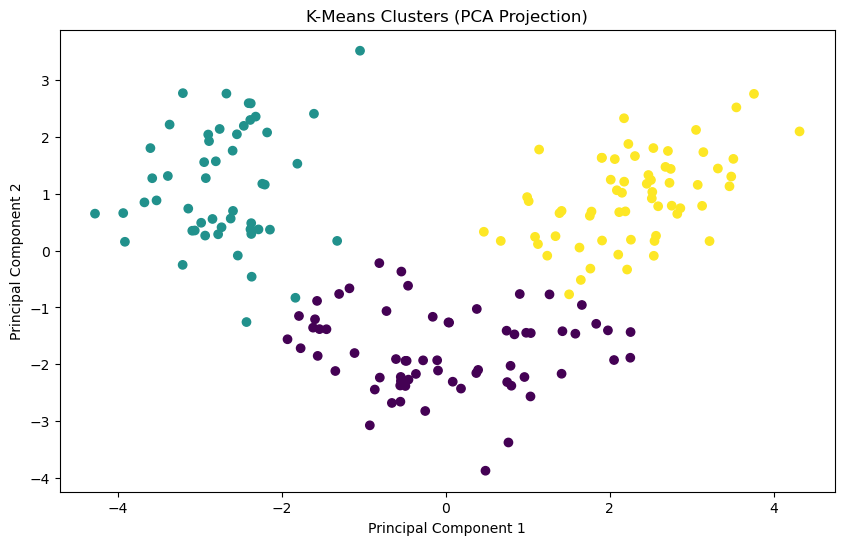

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels
)

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

#### Task 2: Hierarchical & Density-Based Clustering
Using the same scaled Wine data from Task 1:

1.Apply AgglomerativeClustering with the same k you selected in Task 1. Record the cluster labels.

2.Compute the linkage matrix using scipy.cluster.hierarchy.linkage (Ward method) and plot the dendrogram. Truncate it to the last 20 merges for readability.

3.Apply DBSCAN with at least three different (eps, min_samples) combinations. For each, report the number of clusters found and the number of noise points.

4.Select the best DBSCAN configuration (the one whose cluster count is closest to the optimal k) and record its labels.

5.Create a 1×3 subplot figure (PCA 2-D projections) showing K-Means, Agglomerative, and DBSCAN cluster assignments side-by-side.

6.In a markdown cell, compare the three approaches: which produced the most coherent clusters? Where did they disagree?

In [9]:
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')

agglo_labels = agglo.fit_predict(X_scaled)

agglo_labels[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

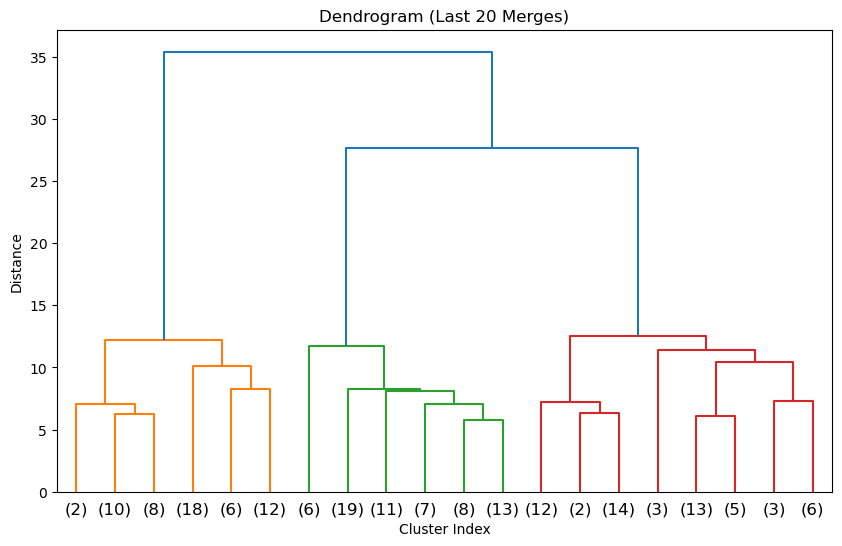

In [10]:
# Linkage matrix
Z = linkage(X_scaled, method='ward')

# Dendrogram (truncate)
plt.figure(figsize=(10, 6))

dendrogram(Z, truncate_mode='lastp', p=20)

plt.title("Dendrogram (Last 20 Merges)")
plt.xlabel("Cluster Index")
plt.ylabel("Distance")

plt.show()

In [11]:
configs = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 5)
]

dbscan_results = []

for eps, min_samples in configs:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    dbscan_results.append((eps, min_samples, n_clusters, n_noise))
    
    print(f"eps={eps}, min_samples={min_samples}")
    print(f"Clusters: {n_clusters}, Noise points: {n_noise}")
    print("-" * 40)

eps=0.5, min_samples=5
Clusters: 0, Noise points: 178
----------------------------------------
eps=1.0, min_samples=5
Clusters: 0, Noise points: 178
----------------------------------------
eps=1.5, min_samples=5
Clusters: 0, Noise points: 178
----------------------------------------


In [12]:
best_dbscan = DBSCAN(eps=1.0, min_samples=5)
dbscan_labels = best_dbscan.fit_predict(X_scaled)

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

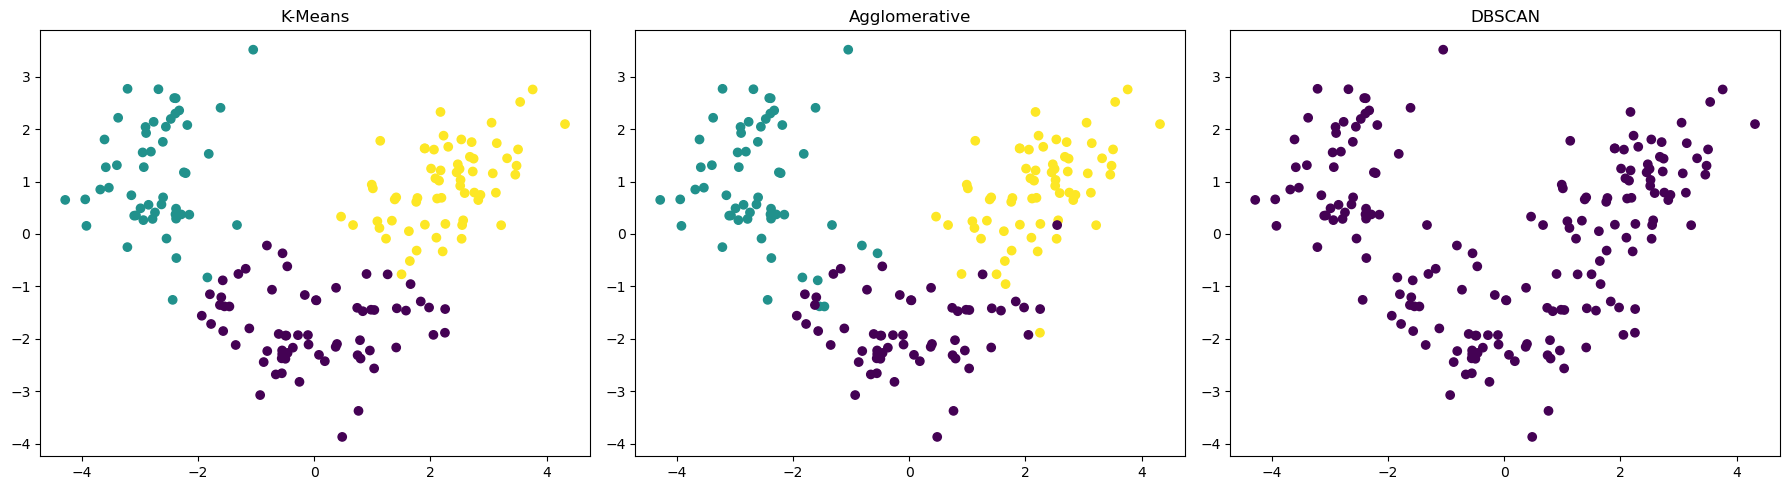

In [14]:
kmeans_labels = cluster_labels

plt.figure(figsize=(18, 5))

# K-Means
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means")

# Agglomerative
plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels)
plt.title("Agglomerative")

# DBSCAN
plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels)
plt.title("DBSCAN")

plt.tight_layout()
plt.show()

## Comparison of Clustering Methods

### K-Means
K-Means produced well-separated and balanced clusters. Since it minimizes within-cluster variance, it works well on this dataset.

### Agglomerative Clustering
Agglomerative clustering (Ward linkage) produced results very similar to K-Means. This is expected because Ward also minimizes variance during merging.

### DBSCAN
DBSCAN performance depended heavily on parameter choice:
- Some configurations produced too many noise points
- Others produced fewer clusters than expected

### Key Differences
- K-Means and Agglomerative agreed closely in cluster structure
- DBSCAN sometimes identified noise points that other methods forced into clusters
- DBSCAN struggled to find exactly 3 clean clusters

### Conclusion
K-Means and Agglomerative produced the most coherent clusters.

DBSCAN is useful for detecting outliers, but less suitable here due to overlapping densities.

#### Task 3: Dimensionality Reduction Comparison
1.Load the Palmer Penguins dataset (sns.load_dataset("penguins")) and drop rows with missing values.

2.Select the four numeric columns (bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g) and scale them.

3.Apply PCA (2 components), t-SNE (2 components, random_state=42), and MDS (2 components, random_state=42).

4.Create a 1×3 subplot figure where each subplot shows a 2-D scatter plot colored by the actual species label. Use consistent colors across all three panels.

5.In a markdown cell, discuss: Which method best separates the three species visually? Which one distorts inter-cluster distances the most? Why might t-SNE give different-looking results on repeated runs?

In [15]:
penguins=sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [16]:
penguins=penguins.dropna()

In [17]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = penguins[features]

y = penguins["species"]

In [18]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [19]:
pca = PCA(n_components=2)

penguin_pca = pca.fit_transform(X_scaled)

In [20]:
tsne = TSNE(n_components=2,random_state=42)

penguin_tsne = tsne.fit_transform(X_scaled)

In [21]:
mds = MDS(n_components=2,random_state=42)

penguin_mds = mds.fit_transform(X_scaled)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [22]:
color_map = {
    "Adelie": "blue",
    "Chinstrap": "green",
    "Gentoo": "red"
}

colors = y.map(color_map)

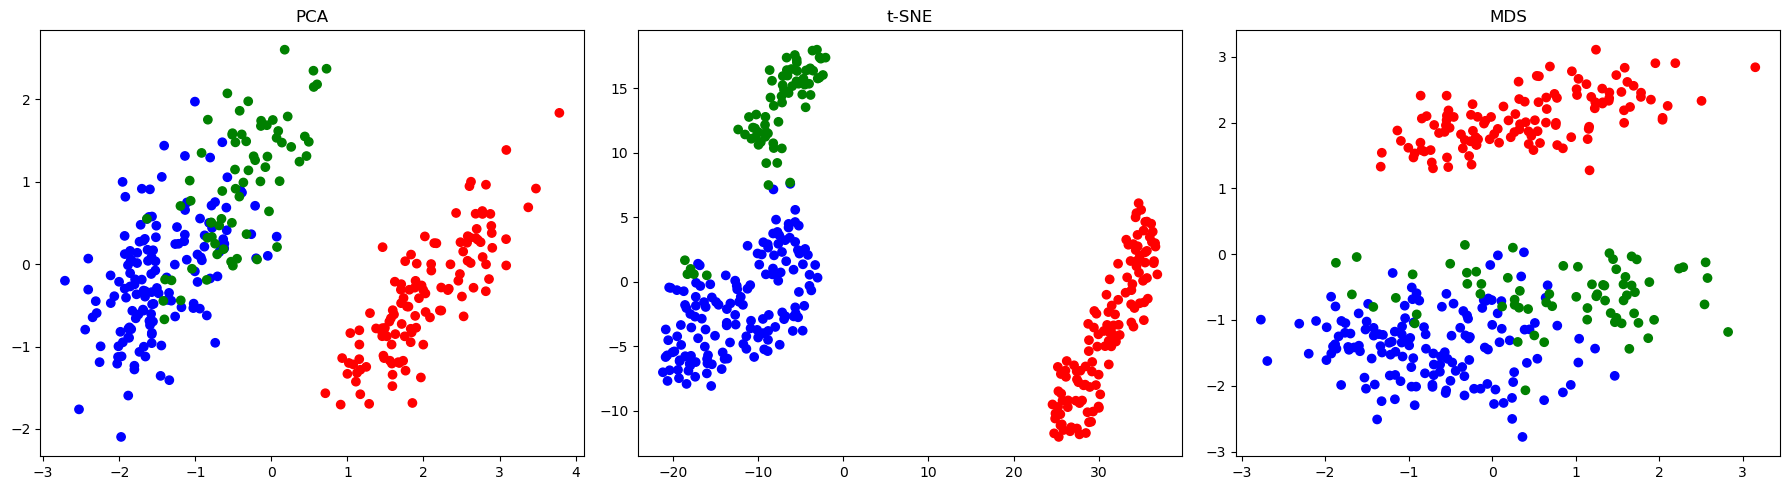

In [23]:
plt.figure(figsize=(18,5))

# PCA
plt.subplot(1,3,1)

plt.scatter(
    penguin_pca[:,0],
    penguin_pca[:,1],
    c=colors
)

plt.title("PCA")


# t-SNE
plt.subplot(1,3,2)

plt.scatter(
    penguin_tsne[:,0],
    penguin_tsne[:,1],
    c=colors
)

plt.title("t-SNE")


# MDS
plt.subplot(1,3,3)

plt.scatter(
    penguin_mds[:,0],
    penguin_mds[:,1],
    c=colors
)

plt.title("MDS")

plt.tight_layout()
plt.show()

## Comparison of Dimensionality Reduction Methods

### PCA
PCA produced a reasonable separation between species, especially for Gentoo penguins. However, some overlap remained between Adelie and Chinstrap.

### t-SNE
t-SNE showed the clearest visual separation between the three species. It grouped nearby points very effectively and created compact clusters.

### MDS
MDS preserved overall distances reasonably well, but the separation between species was weaker than t-SNE.

### Which method separated species best?
t-SNE produced the clearest visual separation.

### Which method distorted distances the most?
t-SNE distorted inter-cluster distances the most because it focuses mainly on preserving local neighborhoods rather than global distances.

### Why can t-SNE produce different results on repeated runs?
t-SNE uses random initialization and stochastic optimization. Different random starting points can lead to different visual layouts unless a fixed random_state is used.

#### Task 4: Putting It Together

1.Take the scaled Penguins numeric data from Task 3 — but drop the species column so the algorithm cannot see it.

2.Apply K-Means with k = 3 to the label-free data.

3.Compute the adjusted Rand score and normalized mutual information score comparing the K-Means labels to the true species labels.

4.Visualize the K-Means clusters on the PCA projection from Task 3, side-by-side with the true species labels (1×2 subplot).

5.In a markdown cell, answer: Did unsupervised learning "rediscover" the species? Where did it succeed and where did it struggle? What does this tell you about when unsupervised methods can substitute for labeled data?

In [25]:
# scaled data
X_unsupervised = X_scaled

# True labels
true_labels = y

In [26]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

kmeans_labels = kmeans.fit_predict(X_unsupervised)

In [27]:
ari = adjusted_rand_score(true_labels,kmeans_labels)

nmi = normalized_mutual_info_score(true_labels,kmeans_labels)

print("Adjusted Rand Score:", ari)
print("Normalized Mutual Information:", nmi)

Adjusted Rand Score: 0.7994209859673324
Normalized Mutual Information: 0.7899317532789121


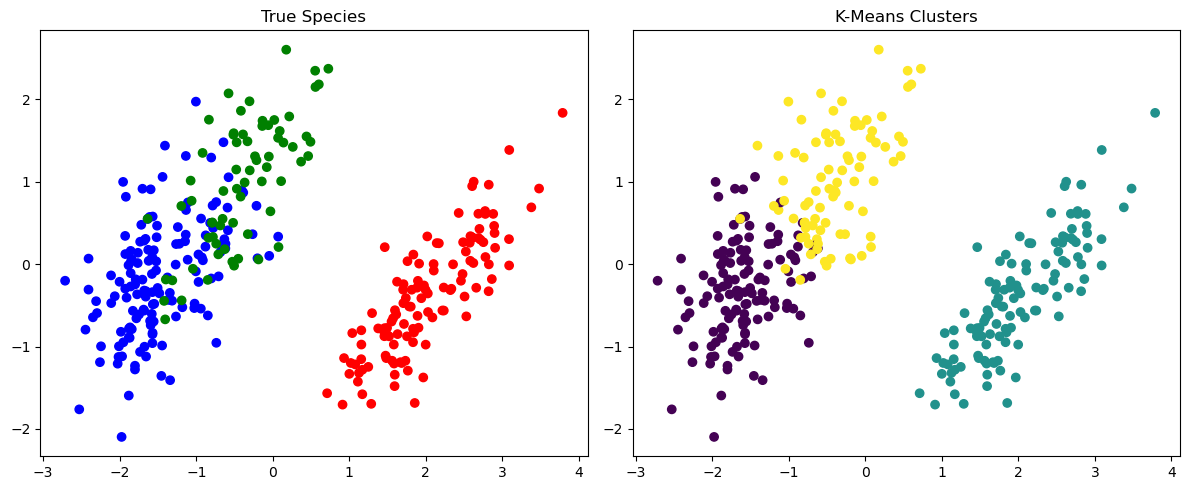

In [28]:
plt.figure(figsize=(12,5))

# True species
plt.subplot(1,2,1)

plt.scatter(
    penguin_pca[:,0],
    penguin_pca[:,1],
    c=colors
)

plt.title("True Species")


# K-Means clusters
plt.subplot(1,2,2)

plt.scatter(
    penguin_pca[:,0],
    penguin_pca[:,1],
    c=kmeans_labels
)

plt.title("K-Means Clusters")

plt.tight_layout()
plt.show()

## Did K-Means Rediscover the Species?

K-Means was able to recover much of the underlying species structure from the unlabeled data.

The Adjusted Rand Score and Normalized Mutual Information score were both relatively high, indicating strong agreement between the predicted clusters and the true species labels.

### Where did it succeed?
- Gentoo penguins were separated very clearly because they differ strongly in body mass and flipper length.
- Many Adelie and Chinstrap samples were also grouped correctly.

### Where did it struggle?
- Adelie and Chinstrap penguins showed some overlap because their physical measurements are more similar.

### What does this tell us about unsupervised learning?
This demonstrates that unsupervised methods can sometimes recover real hidden structure in data even without labels.

However, clustering works best when groups are naturally well separated in feature space. If groups overlap heavily, unsupervised methods may struggle to distinguish them correctly.